# Confronto di δ_int e Q della rete reale con 500 partizioni casuali




In [27]:
import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# Caricamento
g = ig.Graph.Read_GraphML(r"C:\Users\giuli\OneDrive\Documenti\UNI\MAGISTRALE\AnalVisual\AVRC_FinnishTwittersphereProject\Data\climate_19.graphml")

# igraph può caricare il grafo come diretto anche se il file non lo specifica:
# forziamo non-diretto per coerenza con l'analisi precedente
if g.is_directed():
    g = g.as_undirected(combine_edges="first")

N = g.vcount()
E = g.ecount()


# Attributi dei nodi
groups = g.vs["group"]
hiers  = g.vs["hierarchy"]

gc = Counter(groups)
hc = Counter(hiers)

# Indici dei nodi per ogni gruppo
idx_A = [v.index for v in g.vs if v["group"] == "A"]
idx_B = [v.index for v in g.vs if v["group"] == "B"]

sub_idx = {
    lbl: [v.index for v in g.vs if v["hierarchy"] == lbl]
    for lbl in ["A_CORE", "A_PERIPHERY", "B_CORE", "B_PERIPHERY"]
}

all_idx = list(range(N))



In [28]:
def internal_link_density(g, indices):
    """
    δ_int = 2 * L_C / (N_C * (N_C - 1))
    
    Usa g.induced_subgraph() per estrarre il sotto-grafo indotto
    dagli indici passati.
    """
    n = len(indices)
    if n < 2:
        return 0.0
    sub = g.induced_subgraph(indices)
    return 2 * sub.ecount() / (n * (n - 1))


def random_partition_indices(g, k, seed):
    """
    Partiziona i nodi in k gruppi uniformemente a caso.
    Restituisce una lista di liste di indici.
    """
    rng_local = np.random.default_rng(seed)
    labels    = rng_local.integers(0, k, size=g.vcount())
    return [[i for i in range(g.vcount()) if labels[i] == c] for c in range(k)]


def indices_to_membership(g, partition_indices):
    """
    Converte una lista di liste di indici nel vettore 'membership'
    che igraph usa per g.modularity(): membership[i] = id_comunità del nodo i.
    """
    membership = [0] * g.vcount()
    for comm_id, indices in enumerate(partition_indices):
        for idx in indices:
            membership[idx] = comm_id
    return membership


---
## Baseline random: 500 partizioni casuali in 2 gruppi

Partizioniamo i nodi a caso e misuriamo la densità interna media. Poi sovrapponiamo il valore osservato.


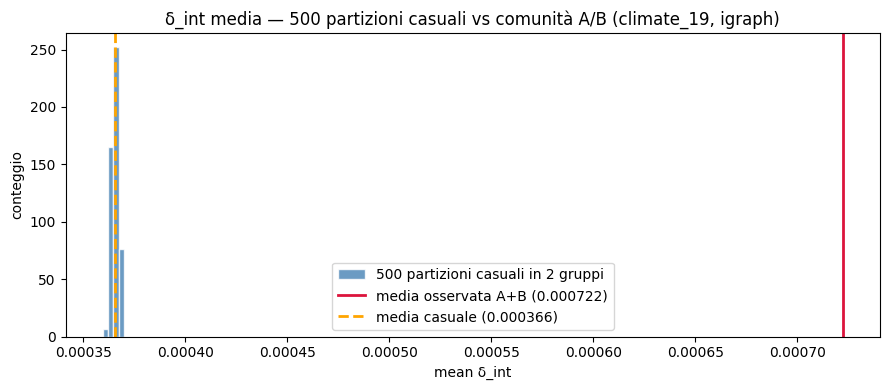

Media casuale  : 0.00036565  (std = 1.69e-06)
Media osservata: 0.00072243
z-score        : 210.7  →  significativo


In [29]:
d_A = internal_link_density(g, idx_A)
d_B = internal_link_density(g, idx_B)
rand_densities_2 = []
for s in range(500):
    part = random_partition_indices(g, k=2, seed=s)
    dens = [internal_link_density(g, C) for C in part if len(C) > 1]
    rand_densities_2.append(np.mean(dens) if dens else 0.0)

rand_mean = np.mean(rand_densities_2)
rand_std  = np.std(rand_densities_2)
obs_mean  = np.mean([d_A, d_B])

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(rand_densities_2, bins=4, color="steelblue", edgecolor="white", alpha=0.8,
        label="500 partizioni casuali in 2 gruppi")
ax.axvline(obs_mean, color="crimson", linewidth=2,
           label=f"media osservata A+B ({obs_mean:.6f})")
ax.axvline(rand_mean, color="orange", linewidth=2, linestyle="--",
           label=f"media casuale ({rand_mean:.6f})")
ax.set_xlabel("mean δ_int")
ax.set_ylabel("conteggio")
ax.set_title("δ_int media — 500 partizioni casuali vs comunità A/B (climate_19, igraph)")
ax.legend()
plt.tight_layout()
plt.show()

z = (obs_mean - rand_mean) / rand_std
print(f"Media casuale  : {rand_mean:.8f}  (std = {rand_std:.2e})")
print(f"Media osservata: {obs_mean:.8f}")
print(f"z-score        : {z:.1f}  →  {'significativo' if z > 10 else 'non significativo'}")


---
## Z-score per singola comunità (A e B)




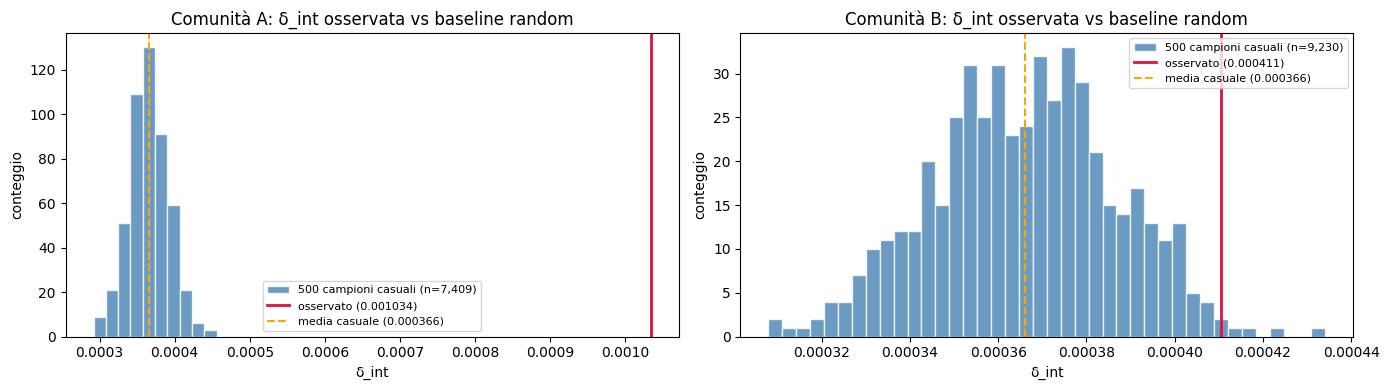

,Comunità,|C|,δ_int osservata,δ_int random mean,z-score
0,A,7409,0.001034,0.000366,25.1
1,B,9230,0.000411,0.000366,2.1


In [30]:

rows = []
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, name, idx_C, obs, bins in zip(axes, ["A", "B"], [idx_A, idx_B], [d_A, d_B], [10,40]):
    baseline = [
        internal_link_density(g, rng.choice(all_idx, size=len(idx_C), replace=False).tolist())
        for _ in range(500)
    ]
    b_mean = np.mean(baseline)
    b_std  = np.std(baseline)
    z      = (obs - b_mean) / b_std

    ax.hist(baseline, bins, color="steelblue", edgecolor="white", alpha=0.8,
            label=f"500 campioni casuali (n={len(idx_C):,})")
    ax.axvline(obs,    color="crimson", linewidth=2,
               label=f"osservato ({obs:.6f})")
    ax.axvline(b_mean, color="orange",  linewidth=1.5, linestyle="--",
               label=f"media casuale ({b_mean:.6f})")
    ax.set_title(f"Comunità {name}: δ_int osservata vs baseline random")
    ax.set_xlabel("δ_int"); ax.set_ylabel("conteggio")
    ax.legend(fontsize=8)

    rows.append({
        "Comunità"             : name,
        "|C|"                  : len(idx_C),
        "δ_int osservata"      : round(obs, 6),
        "δ_int random mean"    : round(b_mean, 6),
        "z-score"              : round(z, 1),
        
    })

plt.tight_layout()
plt.show()
display(pd.DataFrame(rows))


---
## Sotto-partizione CORE / PERIPHERY

Viene carino ma non so se ha senso


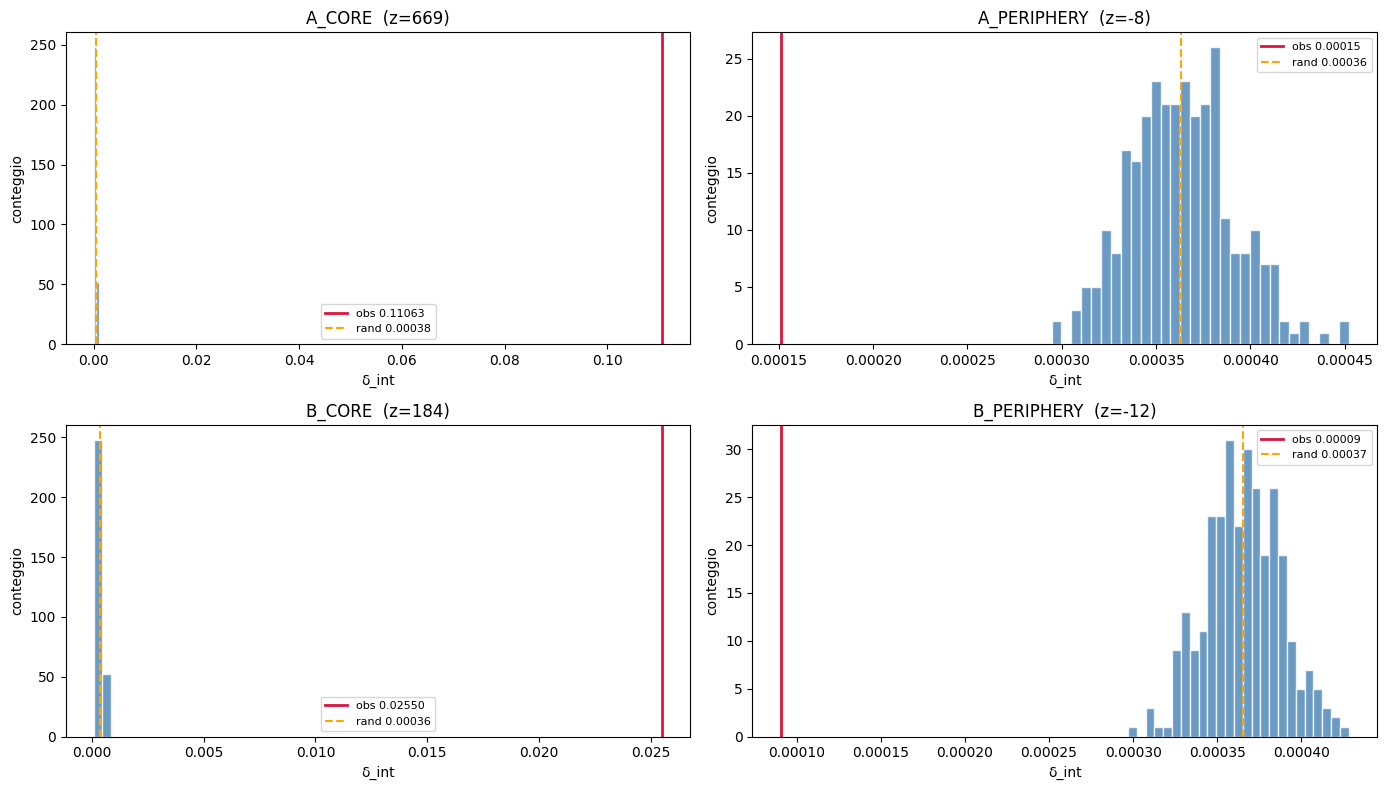

,Sotto-comunità,|C|,δ_int osservata,δ_int random mean,z-score
0,A_CORE,362,0.110635,0.000376,668.7
1,A_PERIPHERY,7047,0.000151,0.000363,-7.8
2,B_CORE,458,0.025503,0.000356,184.0
3,B_PERIPHERY,8772,0.000091,0.000365,-12.3


In [31]:
sub_rows = []
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, lbl, bins in zip(axes.flat, ["A_CORE", "A_PERIPHERY", "B_CORE", "B_PERIPHERY"], [2,30,2,25]):
    C   = sub_idx[lbl]
    obs = internal_link_density(g, C)
    baseline = [
        internal_link_density(g, rng.choice(all_idx, size=len(C), replace=False).tolist())
        for _ in range(300)
    ]
    b_mean = np.mean(baseline)
    b_std  = np.std(baseline)
    z      = (obs - b_mean) / b_std if b_std > 0 else float("inf")

    ax.hist(baseline, bins, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(obs,    color="crimson", linewidth=2, label=f"obs {obs:.5f}")
    ax.axvline(b_mean, color="orange",  linewidth=1.5, linestyle="--",
               label=f"rand {b_mean:.5f}")
    ax.set_title(f"{lbl}  (z={z:.0f})")
    ax.set_xlabel("δ_int"); ax.set_ylabel("conteggio")
    ax.legend(fontsize=8)

    sub_rows.append({
        "Sotto-comunità"    : lbl,
        "|C|"               : len(C),
        "δ_int osservata"   : round(obs, 6),
        "δ_int random mean" : round(b_mean, 6),
        "z-score"           : round(z, 1),
    })

plt.tight_layout()
plt.show()
display(pd.DataFrame(sub_rows))



## Modularity Q 
Anche tutta questa sezione non so se ha senso




In [32]:
def my_modularity_igraph(g, partition_indices):
    """
    Forma community-based di Q — implementata con le API igraph.
    partition_indices: lista di liste di indici interi.
    """
    L      = g.ecount()
    if L == 0:
        return 0.0
    deg    = g.degree()            # lista: deg[i] = grado del nodo i
    two_m  = 2 * L
    Q      = 0.0
    for indices in partition_indices:
        if len(indices) < 2:
            continue
        sub   = g.induced_subgraph(indices)
        L_C   = sub.ecount()
        k_C   = sum(deg[i] for i in indices)
        Q    += L_C / L - (k_C / two_m) ** 2
    return Q


In [ ]:
#Q per i casi chiave 

# Casi patologici
memb_all_one    = [0] * N
memb_singletons = list(range(N))
memb_AB         = indices_to_membership(g, [idx_A, idx_B])
memb_4          = indices_to_membership(g, list(sub_idx.values()))

Q_all_one    = g.modularity(memb_all_one)
Q_singletons = g.modularity(memb_singletons)
Q_AB         = g.modularity(memb_AB)
Q_4parts     = g.modularity(memb_4)


print(f"  Tutti in una sola comunità  : Q = {Q_all_one:.4f}  (atteso: 0)")
print(f"  Ognuno nella propria        : Q = {Q_singletons:.4f}  (atteso: negativo o ~0)")
print(f"  Partizione A / B            : Q = {Q_AB:.4f}")
print(f"  Partizione 4 sotto-gruppi   : Q = {Q_4parts:.4f}")


Sanity checks:
  Tutti in una sola comunità  : Q = 0.0000  (atteso: 0)
  Ognuno nella propria        : Q = -0.0011  (atteso: negativo o ~0)
  Partizione A / B            : Q = 0.3833
  Partizione 4 sotto-gruppi   : Q = 0.0740


In [39]:
#Q per 500 partizioni casuali
Q_random_2 = []
for s in range(500):
    part  = random_partition_indices(g, k=2, seed=s)
    memb  = indices_to_membership(g, part)
    Q_random_2.append(g.modularity(memb))

Q_rand_mean = np.mean(Q_random_2)
Q_rand_std  = np.std(Q_random_2)
z_AB        = (Q_AB - Q_rand_mean) / Q_rand_std

print(f"\nQ casuale medio = {Q_rand_mean:.4f}  (std = {Q_rand_std:.4f})")
print(f"Q osservato A/B = {Q_AB:.4f}")
print(f"z-score Q(A/B)  = {z_AB:.1f}")



Q casuale medio = -0.0005  (std = 0.0023)
Q osservato A/B = 0.3833
z-score Q(A/B)  = 163.5


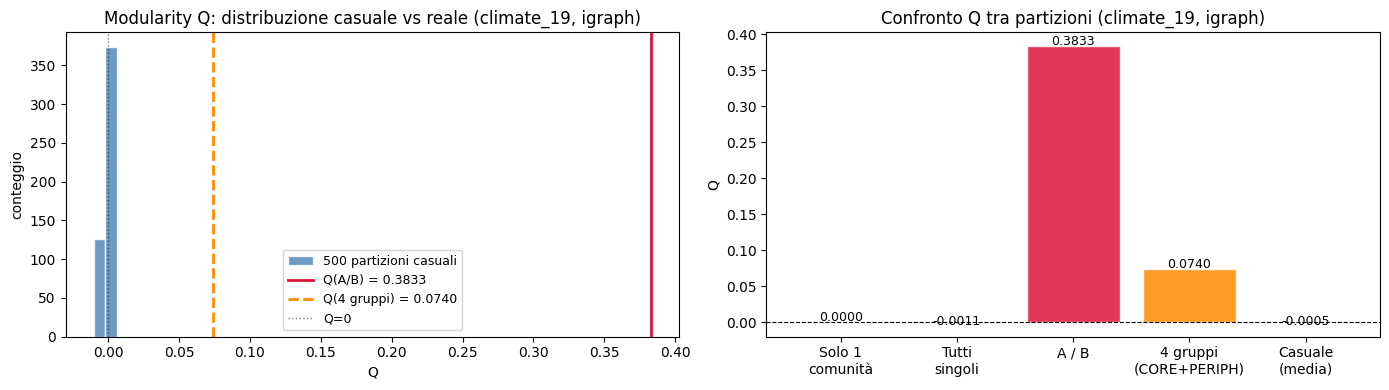

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(Q_random_2, bins=2, color="steelblue", edgecolor="white", alpha=0.8,
        label="500 partizioni casuali")
ax.axvline(Q_AB,     color="crimson",    linewidth=2, label=f"Q(A/B) = {Q_AB:.4f}")
ax.axvline(Q_4parts, color="darkorange", linewidth=2, linestyle="--",
           label=f"Q(4 gruppi) = {Q_4parts:.4f}")
ax.axvline(0, color="black", linewidth=1, linestyle=":", alpha=0.5, label="Q=0")
ax.set_xlabel("Q"); ax.set_ylabel("conteggio")
ax.set_title("Modularity Q: distribuzione casuale vs reale (climate_19, igraph)")
ax.legend(fontsize=9)

ax2 = axes[1]
names_b = ["Solo 1\ncomunità", "Tutti\nsingoli", "A / B", "4 gruppi\n(CORE+PERIPH)", "Casuale\n(media)"]
vals_b  = [Q_all_one, Q_singletons, Q_AB, Q_4parts, Q_rand_mean]
colors_b = ["grey", "grey", "crimson", "darkorange", "steelblue"]
bars = ax2.bar(names_b, vals_b, color=colors_b, alpha=0.85, edgecolor="white")
for b, v in zip(bars, vals_b):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.001 if v >= 0 else v - 0.003,
             f"{v:.4f}", ha="center", fontsize=9)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_ylabel("Q")
ax2.set_title("Confronto Q tra partizioni (climate_19, igraph)")
plt.tight_layout()
plt.show()
